## Text Classification Project

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load the data

df = pd.read_csv("moviereviews.csv")
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [7]:
# getting some info about the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2000 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [8]:
# Check for missing values
df.isnull().sum()

label      0
review    35
dtype: int64

In [10]:
# Drop missing values

df = df.dropna()

In [11]:
# Checking for missing values again

df.isnull().sum()

label     0
review    0
dtype: int64

In [13]:
# Check for empty reviews

df["review"].str.isspace().sum()

np.int64(27)

In [16]:
# Display empty reviews

df[df["review"].str.isspace()]

,label,review
57,neg,
71,pos,
147,pos,
151,pos,
283,pos,
307,pos,
313,neg,
323,pos,
343,pos,
351,neg,


In [18]:
# Remove empty reviews

df = df[~df["review"].str.isspace()]

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [20]:
# Check for empty reviews to verify that they have been removed

df["review"].str.isspace().sum()

np.int64(0)

In [39]:
df["label"].value_counts()

label
neg    969
pos    969
Name: count, dtype: int64

/var/folders/3m/js66k40s0h7dlwq3dhmrr12m0000gq/T/ipykernel_74378/3862427082.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="viridis")


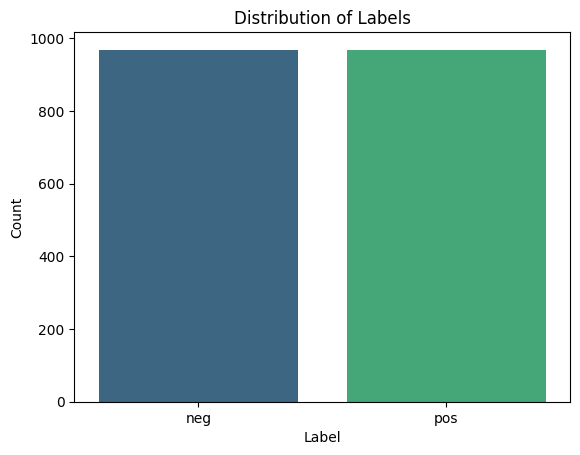

In [40]:
# Check the distribution of labels

sns.countplot(x="label", data=df, palette="viridis")
plt.title("Distribution of Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


### EDA on Bag of Words

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

In [42]:
cv = CountVectorizer(stop_words="english")

In [46]:
# Analyze the most frequent words in negative reviews
# Fit the CountVectorizer on negative reviews and transform them into a document-term matrix
matrix = cv.fit_transform(df[df['label']=='neg']['review'])

# Get the feature names (words) and their total frequencies across all negative reviews
freqs = zip(cv.get_feature_names_out(), matrix.sum(axis=0).tolist()[0])

# Sort the word-frequency pairs by frequency in descending order and print the top 20
print("Top 20 words used for Negative reviews.")
print(sorted(freqs, key=lambda x: -x[1])[:20])

Top 20 words used for Negative reviews.
[('film', 4063), ('movie', 3131), ('like', 1808), ('just', 1480), ('time', 1127), ('good', 1117), ('bad', 997), ('character', 926), ('story', 908), ('plot', 888), ('characters', 838), ('make', 813), ('really', 743), ('way', 734), ('little', 696), ('don', 683), ('does', 666), ('doesn', 648), ('action', 635), ('scene', 634)]


In [47]:
# Analyze the most frequent words in positive reviews
# Fit the CountVectorizer on positive reviews and transform them into a document-term matrix

matrix = cv.fit_transform(df[df['label']=='pos']['review'])

# Get the feature names (words) and their total frequencies across all positive reviews
freqs = zip(cv.get_feature_names_out(), matrix.sum(axis=0).tolist()[0])

# Sort the word-frequency pairs by frequency in descending order and print the top 20
print("Top 20 words used for Positive reviews.")
print(sorted(freqs, key=lambda x: -x[1])[:20])

Top 20 words used for Positive reviews.
[('film', 5002), ('movie', 2389), ('like', 1721), ('just', 1273), ('story', 1199), ('good', 1193), ('time', 1175), ('character', 1037), ('life', 1032), ('characters', 957), ('way', 864), ('films', 851), ('does', 828), ('best', 788), ('people', 769), ('make', 764), ('little', 751), ('really', 731), ('man', 728), ('new', 702)]


## Spliting the data into training and testing

In [48]:
from sklearn.model_selection import train_test_split

In [ ]:
# Extract the features (review texts) from the dataframe
X = df['review']

# Extract the target labels (pos/neg sentiment) from the dataframe
y = df['label']

In [50]:
# Split the data into training (80%) and testing (20%) sets
# test_size=0.2 means 20% of data goes to test set and 80% to training set
# random_state=42 ensures reproducibility by using a fixed random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)